In [21]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Question 1


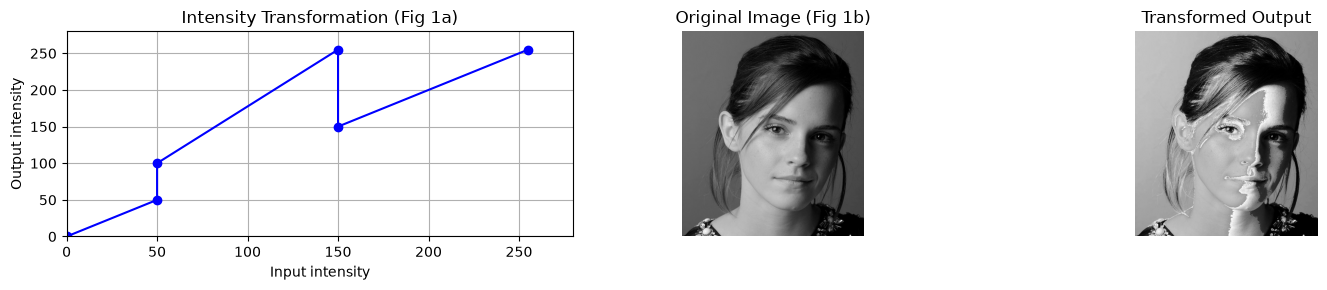

In [26]:
def intensity_transform(im, breakpoints):
    """
    Applies a piecewise linear intensity transformation.
    breakpoints: List of tuples (input_intensity, output_intensity)
    """
    xp, fp = zip(*breakpoints)
    
    # np.interp provides efficient, vectorized 1D linear interpolation
    transformed_im = np.interp(im, xp, fp).astype(np.uint8)
    return transformed_im

# Load the image
img = cv.imread('D:\\EN3160_Assignment_01\\images\\q1.jpeg', cv.IMREAD_GRAYSCALE) 
assert img is not None, "Error: Image not found. Check your file path."

breakpoints = [(0, 0), (50,50),(50,100),(150,255), (150, 150), (255, 255)] 

transformed_img = intensity_transform(img, breakpoints)

fig, ax = plt.subplots(1, 3, figsize=(15, 3))

# 1. Transformation Plot
xp, fp = zip(*breakpoints)
ax[0].plot(xp, fp, marker='o', color='b', linestyle='-')
ax[0].set_title('Intensity Transformation (Fig 1a)')
ax[0].set_xlabel('Input intensity')
ax[0].set_ylabel('Output intensity')
ax[0].set_xlim([0, 280])
ax[0].set_ylim([0, 280])
ax[0].grid(True)

# 2. Original Image
ax[1].imshow(img, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Original Image (Fig 1b)')
ax[1].axis('off')

# 3. Transformed Image
ax[2].imshow(transformed_img, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Transformed Output')
ax[2].axis('off')

plt.tight_layout()
plt.show()

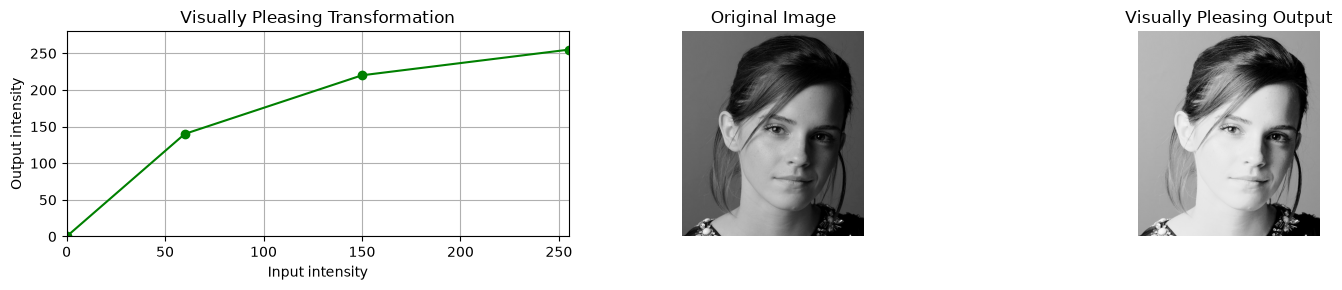

In [27]:
# Breakpoints designed to brighten the underexposed image
pleasing_breakpoints = [(0, 0), (60, 140), (150, 220), (255, 255)]

assert img is not None, "Error: Image not found."

pleasing_transformed_img = intensity_transform(img, pleasing_breakpoints)

fig, ax = plt.subplots(1, 3, figsize=(15, 3))

# 1. Transformation Plot
xp, fp = zip(*pleasing_breakpoints)
ax[0].plot(xp, fp, marker='o', color='g', linestyle='-')
ax[0].set_title('Visually Pleasing Transformation')
ax[0].set_xlabel('Input intensity')
ax[0].set_ylabel('Output intensity')
ax[0].set_xlim([0, 255])
ax[0].set_ylim([0, 280])
ax[0].grid(True)

# 2. Original Image
ax[1].imshow(img, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Original Image')
ax[1].axis('off')

# 3. Transformed Image
ax[2].imshow(pleasing_transformed_img, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Visually Pleasing Output')
ax[2].axis('off')

plt.tight_layout()
plt.show()

# Question 2

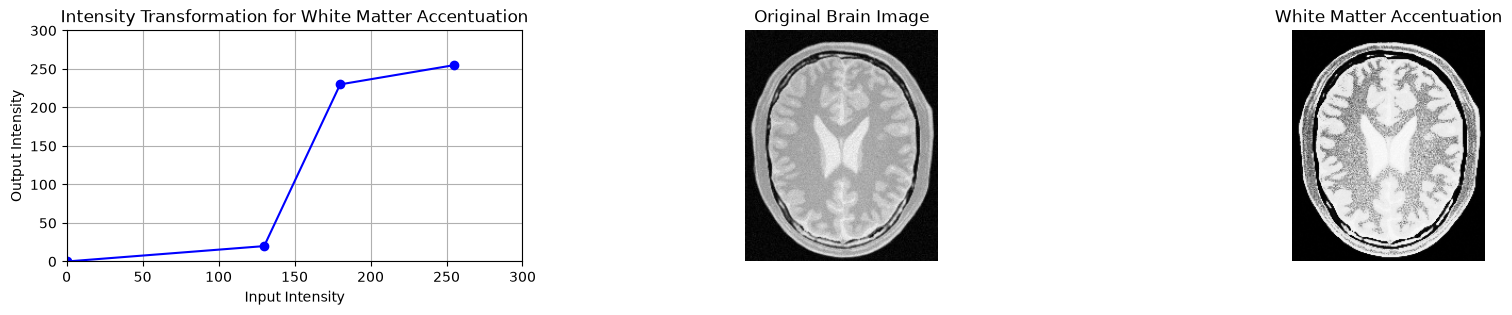

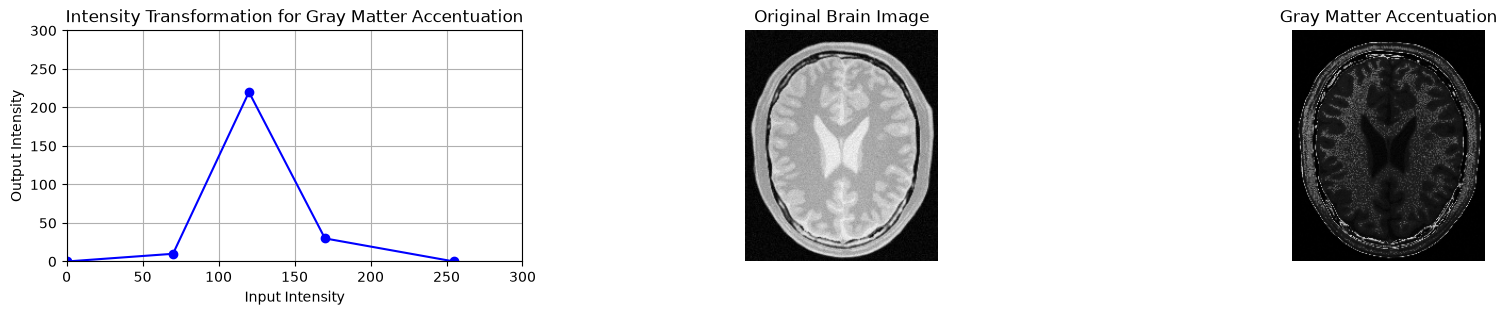

In [31]:
def display_segmentation_results(img_orig, img_transformed, points, target_name):
    """
    Helper function to plot the original image, transformation curve, and result.
    """
    # Unpack breakpoints directly into x and y coordinate tuples
    x_coords, y_coords = zip(*points)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 3))
    
    # Transformation Plot
    axes[0].plot(x_coords, y_coords, marker='o', color='blue', linestyle='-')
    axes[0].set_title(f'Intensity Transformation for {target_name}')
    axes[0].set_xlabel('Input Intensity')
    axes[0].set_ylabel('Output Intensity')
    axes[0].set_xlim([0, 300]) 
    axes[0].set_ylim([0, 300])
    axes[0].grid(True)

    # Original Image
    axes[1].imshow(img_orig, cmap='gray', vmin=0, vmax=255)
    axes[1].set_title('Original Brain Image')     
    axes[1].axis('off') 
        
    # Transformed Image
    axes[2].imshow(img_transformed, cmap='gray', vmin=0, vmax=255)
    axes[2].set_title(target_name)
    axes[2].axis('off') 
    
    plt.show()

# Load the image and verify
im_brain = cv.imread("images\\q2.jpeg", cv.IMREAD_GRAYSCALE)
assert im_brain is not None, "Error: Image 'q2.jpeg' could not be loaded."

# --- White Matter Accentuation ---
wm_breakpoints = [
    (0, 0),
    (130, 20),   # Suppress CSF and Gray Matter
    (180, 230),  # Steep stretch across White Matter range
    (255, 255)   # Max out bright regions
]

wm_image = intensity_transform(im_brain, wm_breakpoints)
display_segmentation_results(im_brain, wm_image, wm_breakpoints, 'White Matter Accentuation')

# --- Gray Matter Accentuation ---
gm_breakpoints = [
    (0, 0),
    (70, 10),    # Suppress dark background / CSF
    (120, 220),  # Steep stretch across Gray Matter range
    (170, 30),   # Drop bright White Matter to keep Gray Matter visually dominant
    (255, 0)
]

gm_image = intensity_transform(im_brain, gm_breakpoints)
display_segmentation_results(im_brain, gm_image, gm_breakpoints, 'Gray Matter Accentuation')